<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/w5n1_stat_methods_ml_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 9-  Statistical Methods for Machine Learning & Feature Selection
### Statistics & Quantitative Methods for Data Science

Every statistical tool from Weeks 1-4 shows up again inside machine learning — just wearing a different name. This class connects the dots and introduces **feature selection**: using statistics to decide *which* variables are worth feeding into a model.

**This notebook:**
1. Why ML needs statistics: train/test split & the generalization problem
2. Feature scaling — why and how
3. Filter-based feature selection: correlation, ANOVA F-test, chi-square
4. Mutual information
5. A worked feature-selection pipeline
6. Class imbalance, statistically
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, SelectKBest

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Why ML needs statistics: the generalization problem

A model that fits training data perfectly can still fail on new data — this is **overfitting**. The **train/test split** directly uses the sampling logic from Week 2: your training set is a *sample*; if a model latches onto quirks of that one sample rather than the true underlying pattern, it won't generalize, exactly like a confidence interval built from a bad sample misses the true population value.

In [ ]:
features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df = titanic.dropna(subset=features + ['survived']).copy()
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}   Test size: {len(X_test)}")
print(f"Survival rate -- train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
print("(stratify=y keeps the class balance the same in both splits -- itself a form of stratified sampling from Week 2!)")

Train size: 571   Test size: 143
Survival rate -- train: 0.406, test: 0.406
(stratify=y keeps the class balance the same in both splits -- itself a form of stratified sampling from Week 2!)


---
# 2. Feature scaling — why and how

Many ML algorithms (e.g. distance-based or gradient-based methods) are sensitive to the **scale** of features. `age` (0-80) and `fare` (0-500+) live on very different scales — without scaling, `fare` would dominate purely due to its larger numbers, not because it's more informative. **Standardization** rescales each feature to the z-score from Week 1: mean 0, std 1.

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)

print("Before scaling:")
print(X_train.describe().loc[['mean', 'std']].round(2))
print("\nAfter scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))
print("\n-> Every feature now has mean~0, std~1 -- this IS the z-score formula from Week 1, applied feature-by-feature.")

Before scaling:
      pclass    age  sibsp  parch   fare
mean    2.24  29.33   0.51   0.44  33.70
std     0.84  14.49   0.95   0.87  51.76

After scaling:
      pclass  age  sibsp  parch  fare
mean     0.0 -0.0   -0.0    0.0  -0.0
std      1.0  1.0    1.0    1.0   1.0

-> Every feature now has mean~0, std~1 -- this IS the z-score formula from Week 1, applied feature-by-feature.


> **Important**: the scaler is `fit` on the training data only, then applied (`.transform`) to the test data — fitting on the full dataset would leak test-set information into training, a subtle but common mistake.

---
# 3. Filter-based feature selection

**Filter methods** score each feature's relationship to the target *independently*, using the statistical tests we already know, then keep the top-scoring features.

- **Numeric feature, numeric target**: correlation (Week 4)
- **Numeric feature, categorical target**: ANOVA F-test (Week 3 — same F-statistic!)
- **Categorical feature, categorical target**: chi-square (Week 3)

In [ ]:
# ANOVA F-test: does each numeric feature differ significantly across the two survived classes?
f_scores, p_values = f_classif(X_train, y_train)

f_test_results = pd.DataFrame({'feature': features, 'F-score': f_scores, 'p-value': p_values}) \
    .sort_values('F-score', ascending=False)
print(f_test_results)
print("\n-> Higher F-score = feature means differ more between survived/died -> more useful for classification.")

  feature    F-score       p-value
0  pclass  87.399775  2.005521e-19
4    fare  40.689297  3.698320e-10
3   parch   6.096192  1.383995e-02
1     age   4.466357  3.500330e-02
2   sibsp   0.130501  7.180477e-01

-> Higher F-score = feature means differ more between survived/died -> more useful for classification.


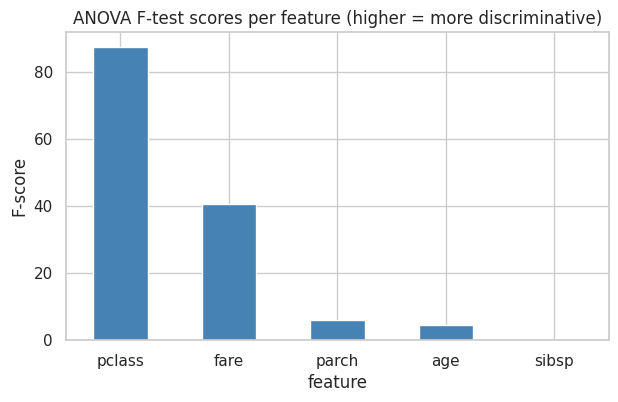

In [ ]:
f_test_results.plot(x='feature', y='F-score', kind='bar', legend=False, color='steelblue')
plt.title('ANOVA F-test scores per feature (higher = more discriminative)')
plt.ylabel('F-score'); plt.xticks(rotation=0)
plt.show()

In [ ]:
# Chi-square needs non-negative values -- appropriate for a categorical feature like pclass, sex
cat_df = titanic.dropna(subset=['pclass', 'sex', 'survived']).copy()
cat_df['sex_code'] = cat_df['sex'].map({'male': 0, 'female': 1})

X_cat = cat_df[['pclass', 'sex_code']]
chi2_scores, chi2_p = chi2(X_cat, cat_df['survived'])
print(pd.DataFrame({'feature': ['pclass', 'sex_code'], 'chi2': chi2_scores, 'p-value': chi2_p}))

    feature        chi2       p-value
0    pclass   30.873699  2.753786e-08
1  sex_code  170.348127  6.210585e-39


---
# 4. Mutual information

Correlation and ANOVA only catch **linear / mean-shift** relationships. **Mutual information** measures *any* kind of statistical dependency (linear or not) between a feature and the target, in bits of shared information — 0 means truly independent.

  feature  mutual_info
4    fare     0.118024
0  pclass     0.091005
1     age     0.030919
3   parch     0.024313
2   sibsp     0.000000


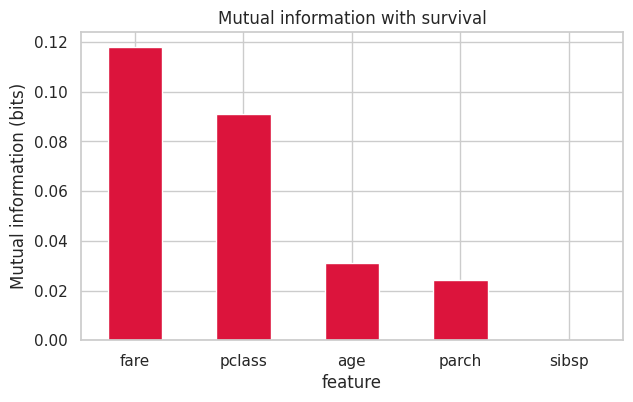

In [ ]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_results = pd.DataFrame({'feature': features, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
print(mi_results)

mi_results.plot(x='feature', y='mutual_info', kind='bar', legend=False, color='crimson')
plt.title('Mutual information with survival')
plt.ylabel('Mutual information (bits)'); plt.xticks(rotation=0)
plt.show()

---
# 5. A worked feature-selection pipeline

`SelectKBest` automates "score every feature, keep the top k" using any of the scoring functions above.

In [ ]:
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
print(f"Top 3 features by ANOVA F-test: {list(selected_features)}")

scores_df = pd.DataFrame({'feature': features, 'score': selector.scores_, 'selected': selector.get_support()})
print(scores_df.sort_values('score', ascending=False))

Top 3 features by ANOVA F-test: ['pclass', 'parch', 'fare']
  feature      score  selected
0  pclass  87.399775      True
4    fare  40.689297      True
3   parch   6.096192      True
1     age   4.466357     False
2   sibsp   0.130501     False


---
# 6. Class imbalance, statistically

If one class dominates (e.g. 90% did-not-survive), a model can get 90% accuracy by *always* predicting the majority class — useless in practice. This connects to Week 3's proportion confidence intervals: with few minority-class examples, any statistic estimated *within* that class has a wide margin of error, so the model has little reliable signal to learn from.

In [ ]:
print("Class balance in full data:")
print(titanic['survived'].value_counts(normalize=True).round(3))

# A wide CI on the minority group illustrates the problem directly
minority = titanic[titanic.survived == 1]
p_hat = minority['pclass'].eq(1).mean()
se = np.sqrt(p_hat*(1-p_hat)/len(minority))
ci = stats.norm.interval(0.95, loc=p_hat, scale=se)
print(f"\nEven WITHIN the survivors (n={len(minority)}), the proportion who were 1st class has a")
print(f"95% CI of [{ci[0]:.3f}, {ci[1]:.3f}] -- a wide range because the group itself is a small subsample.")
print("With even fewer minority-class examples, per-class statistics get even less reliable.")

Class balance in full data:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Even WITHIN the survivors (n=342), the proportion who were 1st class has a
95% CI of [0.346, 0.450] -- a wide range because the group itself is a small subsample.
With even fewer minority-class examples, per-class statistics get even less reliable.


---
# 7. Exercises

1. Fit a `StandardScaler` on `X_train`, transform `X_test` with it (not a freshly-fit scaler!), and confirm the *test* set's mean isn't exactly 0 (since the scaler's parameters came only from train).
2. Add `sex_code` (0/1 encoded) to the `features` list and rerun the ANOVA F-test ranking. Where does it land relative to the others?
3. Use `SelectKBest` with `mutual_info_classif` instead of `f_classif`. Does the top-3 feature set change?
4. Using `pd.crosstab`, check the class balance of `survived` within just the 3rd-class passengers. Is it more or less imbalanced than the overall dataset?
5. **Challenge**: Look up `class_weight='balanced'` (available in many scikit-learn classifiers) or the **SMOTE** oversampling technique. In a sentence or two, describe how each statistically addresses the class-imbalance problem from Section 6.
